In [2]:
import numpy as np
import torch

## Turbine Example

In [73]:
import numpy as np
import torch
from test_functions import Turbine
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

filename = 'turbine_hist.pt'
x_input = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0])

thermal_prob = Turbine()
gpmodel = train_multitask_gp(thermal_prob, num_train=10, seed=1111) 
active_learning_loop(gpmodel, acq_method = 'entropy', maxiters = 140, disp = True,
                     save_hist = (x_input, filename, 'openmdao'))

gpmodel.save("turbine_gp_trained.pt")

Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
Iter 33
Iter 34
Iter 35
Iter 36
Iter 37
Iter 38
Iter 39
Iter 40
Iter 41
Iter 42
Iter 43
Iter 44
Iter 45
Iter 46
Iter 47
Iter 48
Iter 49
Iter 50
Iter 51
Iter 52
Iter 53
Iter 54
Iter 55
Iter 56
Iter 57
Iter 58
Iter 59
Iter 60
Iter 61
Iter 62
Iter 63
Iter 64
Iter 65
Iter 66
Iter 67
Iter 68
Iter 69
Iter 70
Iter 71
Iter 72
Iter 73
Iter 74
Iter 75
Iter 76
Iter 77
Iter 78
Iter 79
Iter 80
Iter 81
Iter 82
Iter 83
Iter 84
Iter 85
Iter 86
Iter 87
Iter 88
Iter 89
Iter 90
Iter 91
Iter 92
Iter 93
Iter 94
Iter 95
Iter 96
Iter 97


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


Iter 98
Iter 99
Iter 100
Iter 101
Iter 102
Iter 103
Iter 104
Iter 105
Iter 106
Iter 107
Iter 108


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


Iter 109
Iter 110
Iter 111
Iter 112
Iter 113
Iter 114


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


Iter 115
Iter 116
Iter 117
Iter 118
Iter 119
Iter 120
Iter 121
Iter 122
Iter 123
Iter 124
Iter 125
Iter 126
Iter 127
Iter 128
Iter 129
Iter 130
Iter 131
Iter 132
Iter 133
Iter 134
Iter 135
Iter 136
Iter 137


C:\Users\kaily\miniconda3\envs\bayesian_opt\Lib\site-packages\botorch\fit.py:215: OptimizationWarning: `scipy_minimize` terminated with status OptimizationStatus.FAILURE, displaying original message from `scipy.optimize.minimize`: ABNORMAL: 
  result = optimizer(mll, closure=closure, **optimizer_kwargs)


Iter 138
Iter 139
Iter 140
done


In [3]:
# gpmodel.save("test.pt")
# from gp import TrainedGP
# newmodel = TrainedGP()
# newmodel.load("test.pt")

(0.0, 1.0)

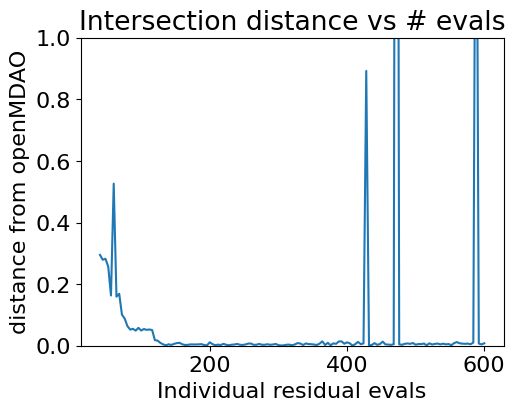

In [4]:
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 16

history = torch.load("turbine_hist.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"] 
intersection_history = history["intersection_history"]
truth_list = history["truth_list"].squeeze()

fig = plt.figure(figsize=(12,4))

ax = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
ax.set_title('Intersection distance vs # evals')
ax.set_xlabel('Individual residual evals')
ax.set_ylabel('distance from openMDAO')
ax.set_ylim((0,1))

### Plot turbine results

#### r2 vs r1

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
import time

plt.rcParams['font.size'] = 16

In [29]:
# USER INPUT
# This assumes that there are two coupling variables that we care about.
tasks = [0,1]

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(input_dim)*(bounds[1, :input_dim] - bounds[0, :input_dim]) + bounds[0, :input_dim] # random input
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)

# Analytic
problem.set_vars(test_points)
t = time.time()
res = problem.res
print(r'elapsed: ', time.time()-t)

elapsed:  103.46576976776123


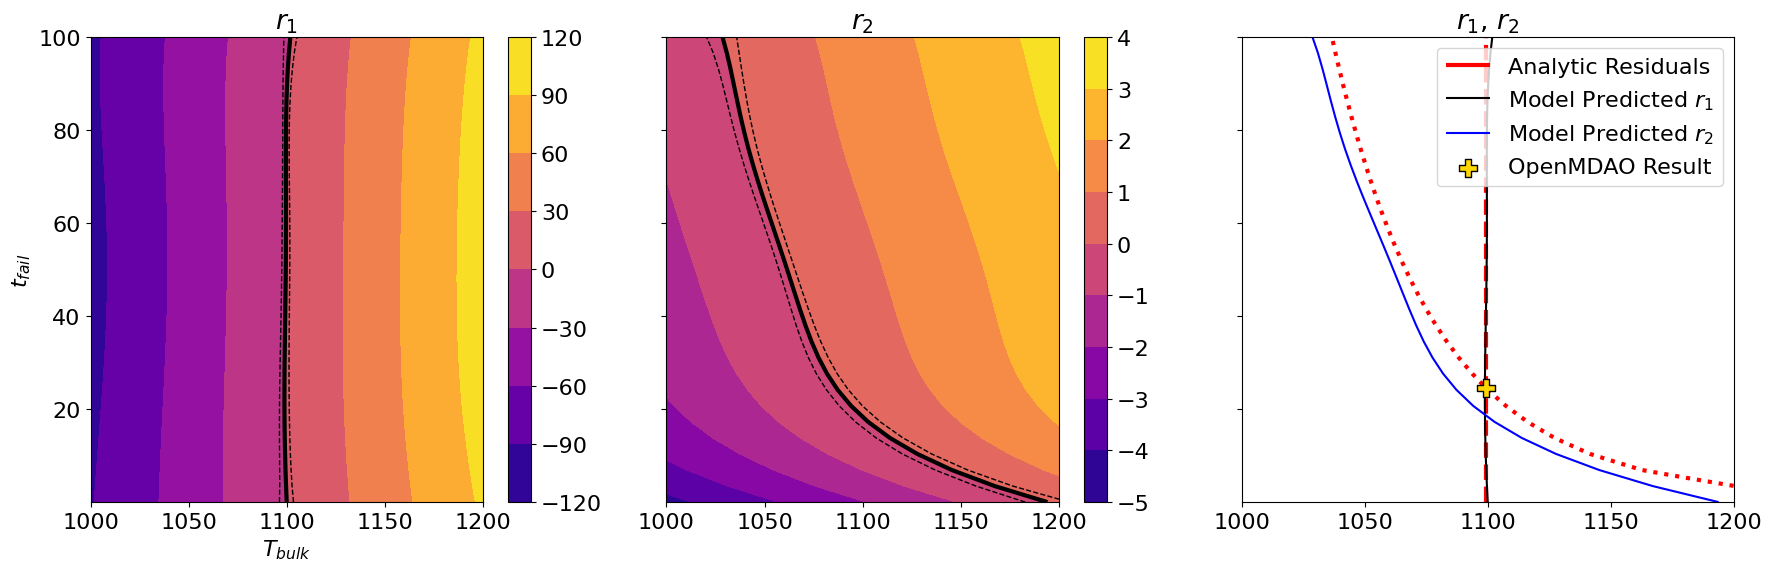

In [30]:
r1vec = res[:,tasks[0]]
r2vec = res[:,tasks[1]]

# Predictions
test_x = normalize(test_points,problem.bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
# test_x1.requires_grad = True

prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$T_{bulk}$')
ax1.set_ylabel(r'$t_{fail}$')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
# ax2.set_xlabel(r'$T_{bulk}$')
# ax2.set_ylabel(r'$t_{fail}$')
ax2.set_yticklabels([])

# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,r2vec.reshape(npts,npts),
#              cmap = 'plasma')
# fig.colorbar(cf3)

s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles=':', linewidths=3, colors='r')

s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='blue')
# s4 = ax3.scatter([1111.3],[10.128],marker='x',c='y',s=3000)
s4 = ax3.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$, $r_2$')
# ax3.set_xlabel(r'$T_{bulk}$')
# ax3.set_ylabel(r'$t_{fail}$')
ax3.set_yticklabels([])

ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])
# ax3.legend([s2_artist[0], s3_artist[0], s4],['Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])

plt.tight_layout()

#### r4 vs r2

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
import time

plt.rcParams['font.size'] = 16

In [32]:
# USER INPUT
# This assumes that there are two coupling variables that we care about.
tasks = [1,3]

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(input_dim)*(bounds[1, :input_dim] - bounds[0, :input_dim]) + bounds[0, :input_dim] # random input
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)

# Analytic
problem.set_vars(test_points)
t = time.time()
res = problem.res
print(r'elapsed: ', time.time()-t)

elapsed:  103.13988995552063


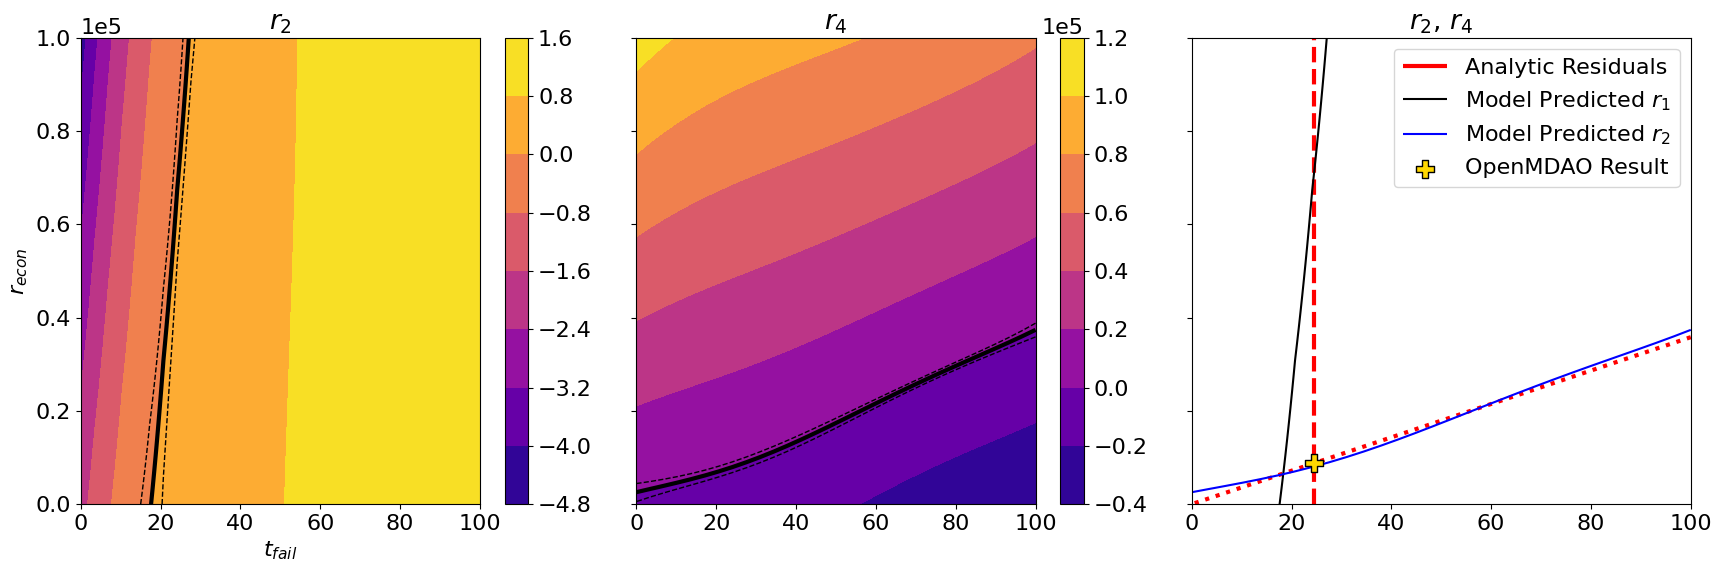

In [33]:
r1vec = res[:,tasks[0]]
r2vec = res[:,tasks[1]]

# Predictions                               )
test_x = normalize(test_points,problem.bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*tasks[0]]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*tasks[1]]) # task id2
# test_x1.requires_grad = True

prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_2$')
ax1.set_xlabel(r'$t_{fail}$')
ax1.set_ylabel(r'$r_{econ}$')
ax1.set_xlim((0,100))


# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))
cbar2 = fig.colorbar(cf2, format=cbformat)
ax2.set_title(r'$r_4$')
# ax2.set_xlabel(r'$T_{bulk}$')
# ax2.set_ylabel(r'$t_{fail}$')
ax2.set_yticklabels([])
ax2.set_xlim((0,100))

# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,r2vec.reshape(npts,npts),
#              cmap = 'plasma')
# fig.colorbar(cf3)

s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles=':', linewidths=3, colors='r')

s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='blue')
# s4 = ax3.scatter([1111.3],[10.128],marker='x',c='y',s=3000)
s4 = ax3.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_2$, $r_4$')
# ax3.set_xlabel(r'$T_{bulk}$')
# ax3.set_ylabel(r'$t_{fail}$')
ax3.set_yticklabels([])
ax3.set_xlim((0,100))

ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])
# ax3.legend([s2_artist[0], s3_artist[0], s4],['Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])

plt.tight_layout()

ax1.ticklabel_format(style='sci', scilimits=(-3,3))


#### r4 vs r3

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
import time

plt.rcParams['font.size'] = 16

In [35]:
# USER INPUT
# This assumes that there are two coupling variables that we care about.
tasks = [2,3]

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(input_dim)*(bounds[1, :input_dim] - bounds[0, :input_dim]) + bounds[0, :input_dim] # random input
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)

# Analytic
problem.set_vars(test_points)
t = time.time()
res = problem.res
print(r'elapsed: ', time.time()-t)

elapsed:  102.241623878479


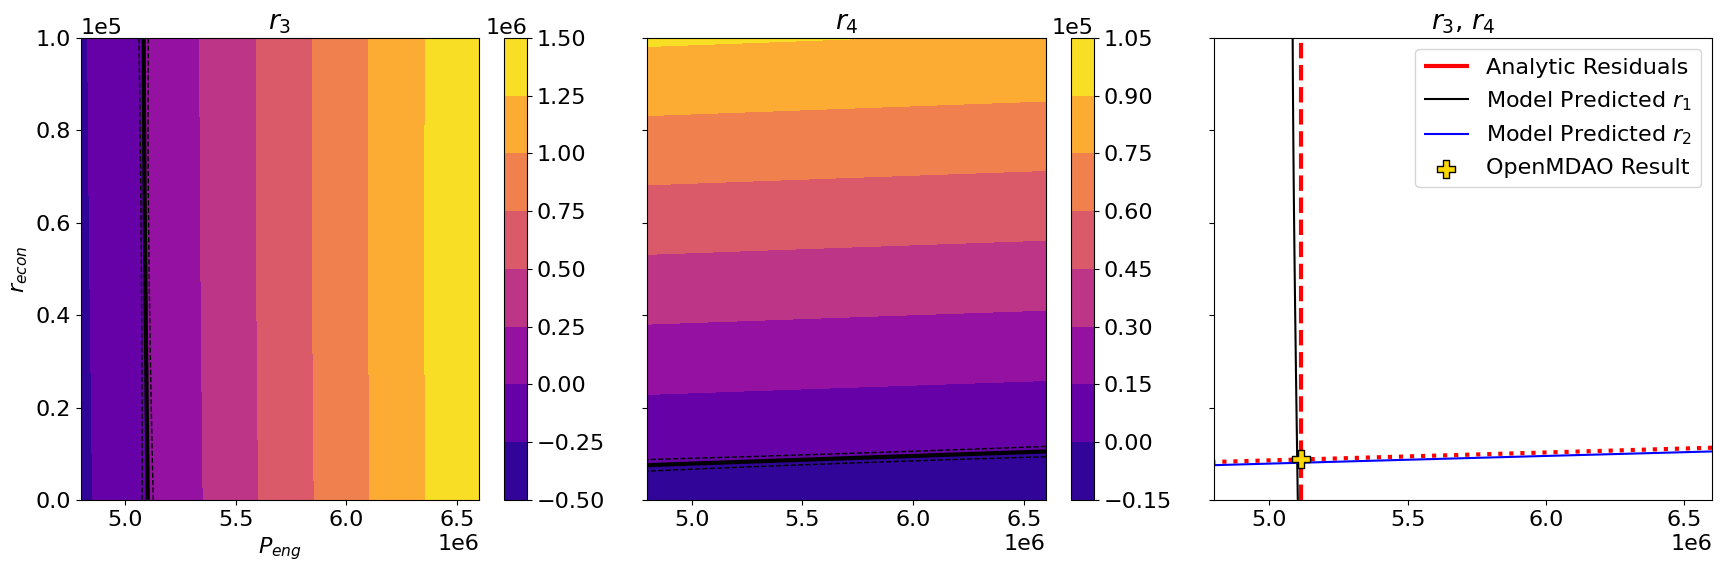

In [36]:
r1vec = res[:,tasks[0]]
r2vec = res[:,tasks[1]]

# Predictions
test_x = normalize(test_points,problem.bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*tasks[0]]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*tasks[1]]) # task id2
# test_x1.requires_grad = True

prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_3$')
ax1.set_xlabel(r'$P_{eng}$')
ax1.set_ylabel(r'$r_{econ}$')
# ax1.set_xlim((0,100))


# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))
cbar2 = fig.colorbar(cf2, format=cbformat)
ax2.set_title(r'$r_4$')
# ax2.set_xlabel(r'$T_{bulk}$')
# ax2.set_ylabel(r'$t_{fail}$')
ax2.set_yticklabels([])
# ax2.set_xlim((0,100))

# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,r2vec.reshape(npts,npts),
#              cmap = 'plasma')
# fig.colorbar(cf3)

s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles=':', linewidths=3, colors='r')

s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='blue')
# s4 = ax3.scatter([1111.3],[10.128],marker='x',c='y',s=3000)
s4 = ax3.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_3$, $r_4$')
# ax3.set_xlabel(r'$T_{bulk}$')
# ax3.set_ylabel(r'$t_{fail}$')
ax3.set_yticklabels([])
# ax3.set_xlim((0,100))

ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])
# ax3.legend([s2_artist[0], s3_artist[0], s4],['Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])

plt.tight_layout()

ax1.ticklabel_format(style='sci', scilimits=(-3,3))


#### r4 vs r1

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
import time

plt.rcParams['font.size'] = 16

In [38]:
# USER INPUT
# This assumes that there are two coupling variables that we care about.
tasks = [0,3]

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(input_dim)*(bounds[1, :input_dim] - bounds[0, :input_dim]) + bounds[0, :input_dim] # random input
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)

# Analytic
problem.set_vars(test_points)
t = time.time()
res = problem.res
print(r'elapsed: ', time.time()-t)

elapsed:  101.13962125778198


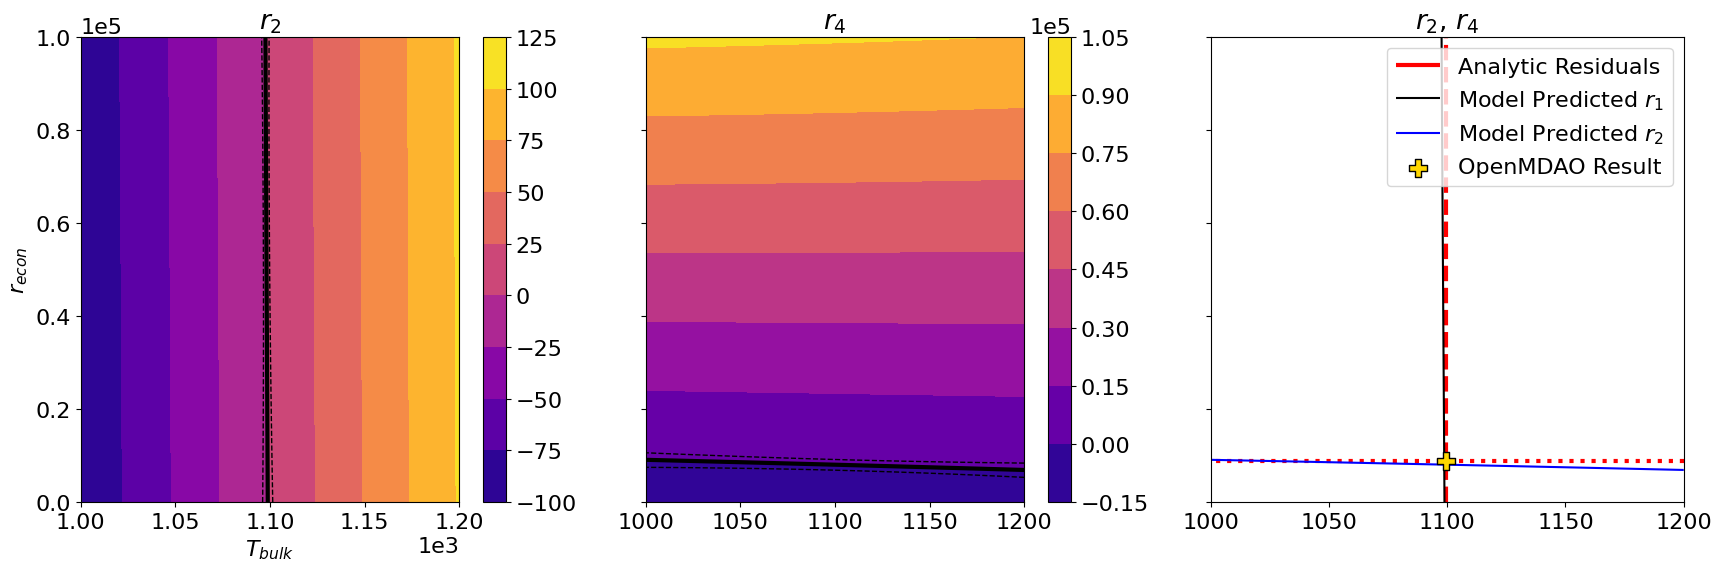

In [39]:
r1vec = res[:,tasks[0]]
r2vec = res[:,tasks[1]]

# Predictions
test_x = normalize(test_points,problem.bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*tasks[0]]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*tasks[1]]) # task id2
# test_x1.requires_grad = True

prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_2$')
ax1.set_xlabel(r'$T_{bulk}$')
ax1.set_ylabel(r'$r_{econ}$')

# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))
cbar2 = fig.colorbar(cf2, format=cbformat)
ax2.set_title(r'$r_4$')
# ax2.set_xlabel(r'$T_{bulk}$')
# ax2.set_ylabel(r'$t_{fail}$')
ax2.set_yticklabels([])

# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,r2vec.reshape(npts,npts),
#              cmap = 'plasma')
# fig.colorbar(cf3)

s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles=':', linewidths=3, colors='r')

s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='blue')
# s4 = ax3.scatter([1111.3],[10.128],marker='x',c='y',s=3000)
s4 = ax3.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_2$, $r_4$')
# ax3.set_xlabel(r'$T_{bulk}$')
# ax3.set_ylabel(r'$t_{fail}$')
ax3.set_yticklabels([])

ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])
# ax3.legend([s2_artist[0], s3_artist[0], s4],['Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])

plt.tight_layout()

ax1.ticklabel_format(style='sci', scilimits=(-3,3))


#### r3 vs r1

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
import time

plt.rcParams['font.size'] = 16

In [41]:
# USER INPUT
# This assumes that there are two coupling variables that we care about.
tasks = [0,2]

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(input_dim)*(bounds[1, :input_dim] - bounds[0, :input_dim]) + bounds[0, :input_dim] # random input
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)

# Analytic
problem.set_vars(test_points)
t = time.time()
res = problem.res
print(r'elapsed: ', time.time()-t)

elapsed:  100.81591582298279


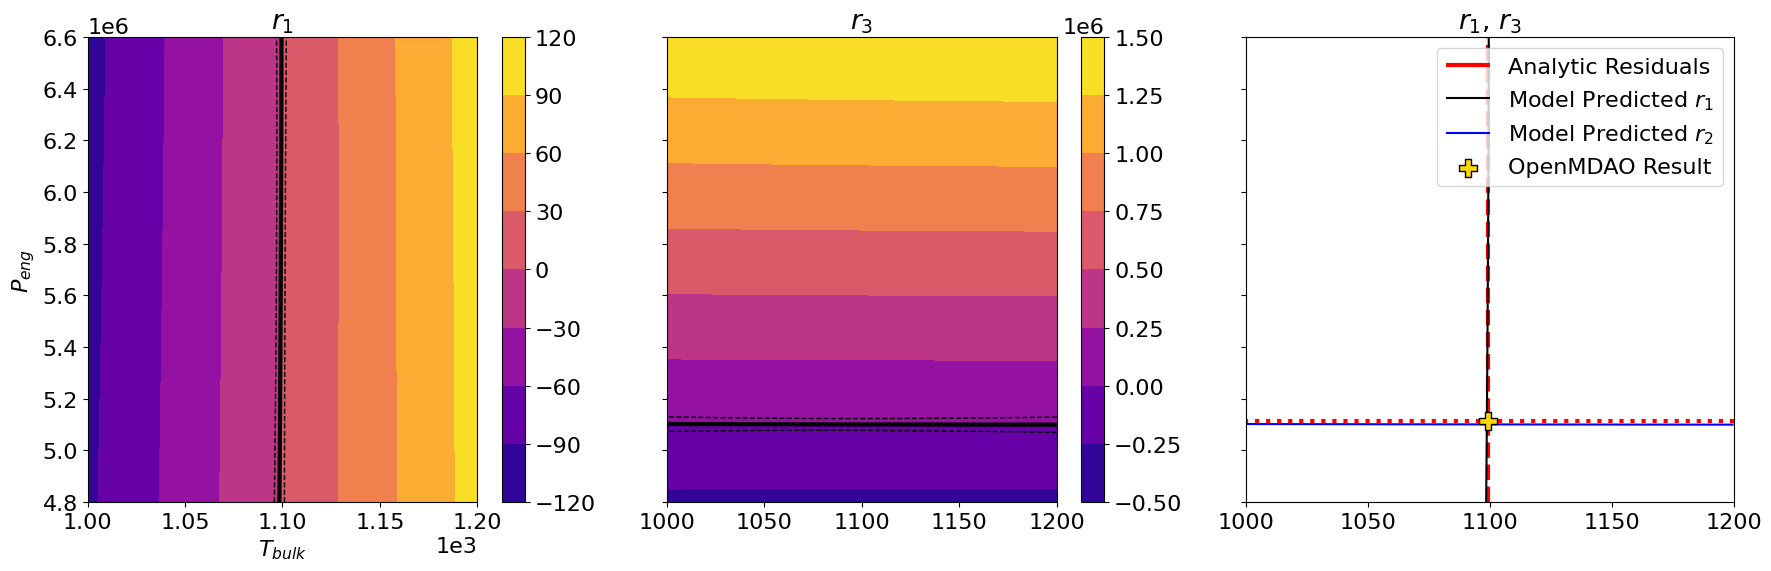

In [42]:
r1vec = res[:,tasks[0]]
r2vec = res[:,tasks[1]]

# Predictions
test_x = normalize(test_points,problem.bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
# test_x1.requires_grad = True

prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$T_{bulk}$')
ax1.set_ylabel(r'$P_{eng}$')

# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))
cbar2 = fig.colorbar(cf2, format=cbformat)
ax2.set_title(r'$r_3$')
# ax2.set_xlabel(r'$T_{bulk}$')
# ax2.set_ylabel(r'$t_{fail}$')
ax2.set_yticklabels([])

# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,r2vec.reshape(npts,npts),
#              cmap = 'plasma')
# fig.colorbar(cf3)

s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles=':', linewidths=3, colors='r')

s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='blue')
# s4 = ax3.scatter([1111.3],[10.128],marker='x',c='y',s=3000)
s4 = ax3.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$, $r_3$')
# ax3.set_xlabel(r'$T_{bulk}$')
# ax3.set_ylabel(r'$t_{fail}$')
ax3.set_yticklabels([])

ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])
# ax3.legend([s2_artist[0], s3_artist[0], s4],['Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])

plt.tight_layout()

ax1.ticklabel_format(style='sci', scilimits=(-3,3))


In [43]:
# from test_functions import Satellite
# from gp import train_multitask_gp
# from acquisition import multitask_acquisition, optimize_acquisition
# from active_learning import active_learning_loop
# from botorch.utils.transforms import normalize, unnormalize, standardize 

# sat_prob = Satellite()
# gpmodel = train_multitask_gp(sat_prob, num_train=10, seed=1111) 

# gpmodel.model

#### r3 vs r2

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
import time

plt.rcParams['font.size'] = 16

In [45]:
# USER INPUT
# This assumes that there are two coupling variables that we care about.
tasks = [1,2]

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(input_dim)*(bounds[1, :input_dim] - bounds[0, :input_dim]) + bounds[0, :input_dim] # random input
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)

# Analytic
problem.set_vars(test_points)
t = time.time()
res = problem.res
print(r'elapsed: ', time.time()-t)

elapsed:  101.54488730430603


In [5]:
# fig = plt.figure(figsize=(12,8))

# for i in range(1,7):
#     ax = fig.add_subplot(2,3,i)
#     if i!=4: 
#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
#     if i==4:
#         plt.scatter(torch.rand(50),torch.rand(50),torch.rand(50))
#     if i==6:
#         plt.plot(torch.rand(5),torch.rand(5))

# plt.tight_layout()

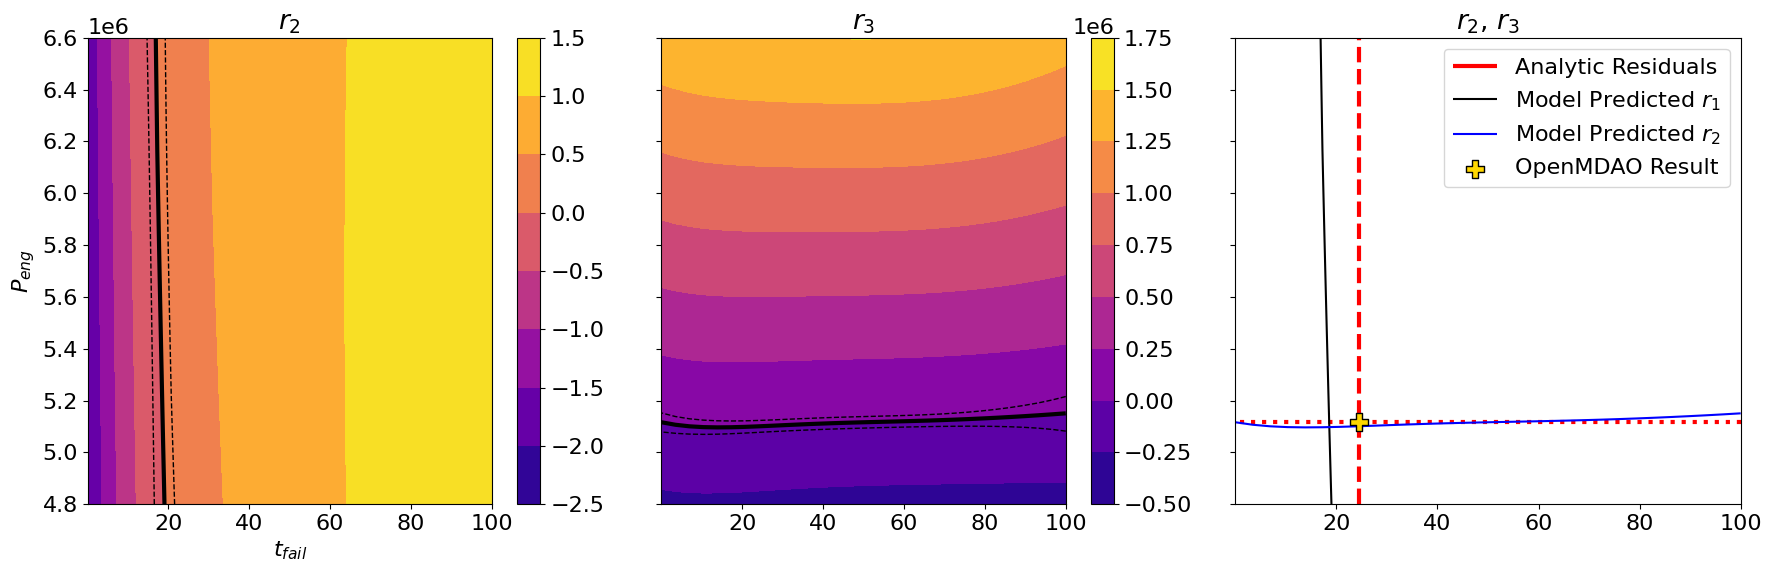

In [46]:
r1vec = res[:,tasks[0]]
r2vec = res[:,tasks[1]]

# Predictions
test_x = normalize(test_points,problem.bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
# test_x1.requires_grad = True

prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

fig = plt.figure(figsize=(18,6))

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1, format=cbformat)
ax1.set_title(r'$r_{%s}$' %(str(tasks[0]+1)))
ax1.set_xlabel(r'$t_{fail}$')
ax1.set_ylabel(r'$P_{eng}$')

# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2, format=cbformat)
ax2.set_title(r'$r_{%s}$' %(str(tasks[1]+1)))
# ax2.set_xlabel(r'$T_{bulk}$')
# ax2.set_ylabel(r'$t_{fail}$')
ax2.set_yticklabels([])

# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,r2vec.reshape(npts,npts),
#              cmap = 'plasma')
# fig.colorbar(cf3)

s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles=':', linewidths=3, colors='r')

s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='blue')
# s4 = ax3.scatter([1111.3],[10.128],marker='x',c='y',s=3000)
s4 = ax3.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_{%s}$, $r_{%s}$' %(str(tasks[0]+1),str(tasks[1]+1)))
# ax3.set_xlabel(r'$T_{bulk}$')
# ax3.set_ylabel(r'$t_{fail}$')
ax3.set_yticklabels([])

ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])
# ax3.legend([s2_artist[0], s3_artist[0], s4],['Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'])

plt.tight_layout()

ax1.ticklabel_format(style='sci', scilimits=(-3,3))


#### residual matrix

fig [0, 1]
fig [0, 2]
fig [0, 3]
fig [1, 2]
fig [1, 3]
fig [2, 3]


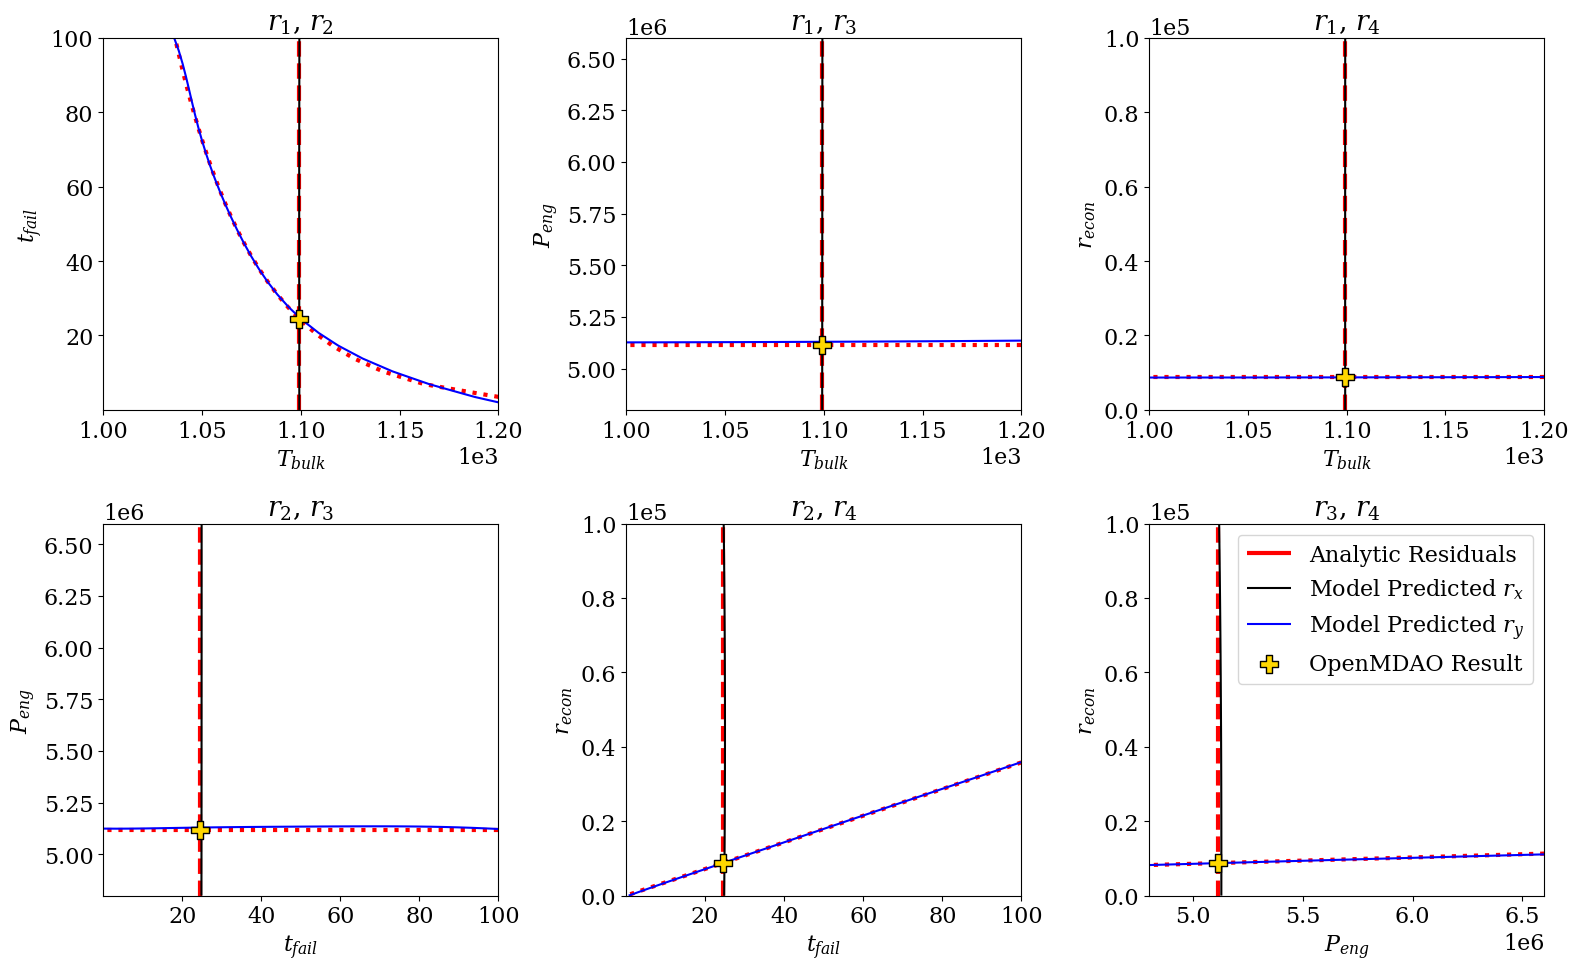

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
# import time

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

# Load model
gpmodel = TrainedGP()
gpmodel.load("turbine_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor([590,640,690,29,1975,975,2.55e4,0.132,1225,0.9,1.0]) # manual input 
truth = problem.from_OpenMDAO(input_vec)

# Plot
fig = plt.figure(figsize=(16,10))

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))

task_pairs = [[0,1],[0,2],[0,3],[1,2],[1,3],[2,3]]
task_names = [r'$T_{bulk}$',r'$t_{fail}$',r'$P_{eng}$',r'$r_{econ}$']

for tasks, figind in zip(task_pairs, range(1,7)):
    print("fig", tasks)
    # t = time.time()
    
    npts = 30
    test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)
    
    # Analytic
    problem.set_vars(test_points)
    res = problem.res

    r1vec = res[:,tasks[0]]
    r2vec = res[:,tasks[1]]
    
    # Predictions
    test_x = normalize(test_points,problem.bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
    test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
    # test_x1.requires_grad = True
    
    prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
    prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

    ax = fig.add_subplot(2,3,figind)

    # Contours
    s1 = ax.contour(xvec,yvec,r1vec.reshape(npts,npts),
                     levels=[0.],
                     linestyles='--', linewidths=3, colors='r')
    s1_artist,_ = s1.legend_elements()
    
    ax.contour(xvec,yvec,r2vec.reshape(npts,npts),
                levels=[0.],
                linestyles=':', linewidths=3, colors='r')
    
    s2 = ax.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='k')
    s2_artist,_ = s2.legend_elements()
    
    s3 = ax.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='blue')
    s3_artist,_ = s3.legend_elements()
    
    s4 = ax.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)

    ax.set_title(r'$r_{%s}$, $r_{%s}$' %(str(tasks[0]+1),str(tasks[1]+1)))
    ax.set_xlabel(task_names[tasks[0]])
    ax.set_ylabel(task_names[tasks[1]])
    ax.ticklabel_format(style='sci', scilimits=(-3,3))

    # print('elapsed:', time.time()-t)
    if figind == 6:
        ax.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],['Analytic Residuals','Model Predicted $r_x$','Model Predicted $r_y$','OpenMDAO Result'])

plt.tight_layout()
plt.savefig("turbine_residual_matrix.svg")
plt.show()

## Satellite Example

In [15]:
import numpy as np
import torch
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 
from scipy.stats import qmc

dtype = torch.float64
device= "cpu"
bounds  = torch.tensor([[0., 0., 0., 0., 0.], 
                        [2., 2., 2., 2., 2.]], dtype=dtype, device=device) # always a 2 x d tensor
# Generate input points
# x_input = unnormalize(torch.rand(10,5), bounds=bounds)
sampler = qmc.LatinHypercube(d=5, seed=1234)
x_input = unnormalize(torch.tensor(sampler.random(n=10)), bounds=bounds)

for i in range(0,20):
    print('Run',i+1,"\r")
    filename = "hist_rep_" + str(i+1) + ".pt"
    # bounds  = torch.tensor([[0., 0., 0., 0., 0.], 
    #                         [2., 2., 2., 2., 2.]], dtype=dtype, device=device) # always a 2 x d tensor
    # x_input = unnormalize(torch.rand(10,5), bounds=bounds)
    
    sat_prob = Satellite()
    gpmodel = train_multitask_gp(sat_prob, num_train=8, seed=1111+i) 
    active_learning_loop(gpmodel,acq_method = 'entropy', maxiters = 32, 
                         disp = True, save_hist = (x_input, filename, 'openmdao'), 
                         log_hyperparams = False)
    # Save result
    gpmodel.save('satellite_gp_trained_' + str(i+1) + '.pt')
    
## Review comment
# It looks like OpenMDAO is called internally to compute the true fixed point. Please make this
# optional and add a flag as a kwarg to turn this on if necessary (default should be off)

Run 1 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
done
Run 2 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
done
Run 3 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
done
Run 4 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
I

Text(0, 0.5, 'distance from openMDAO result')

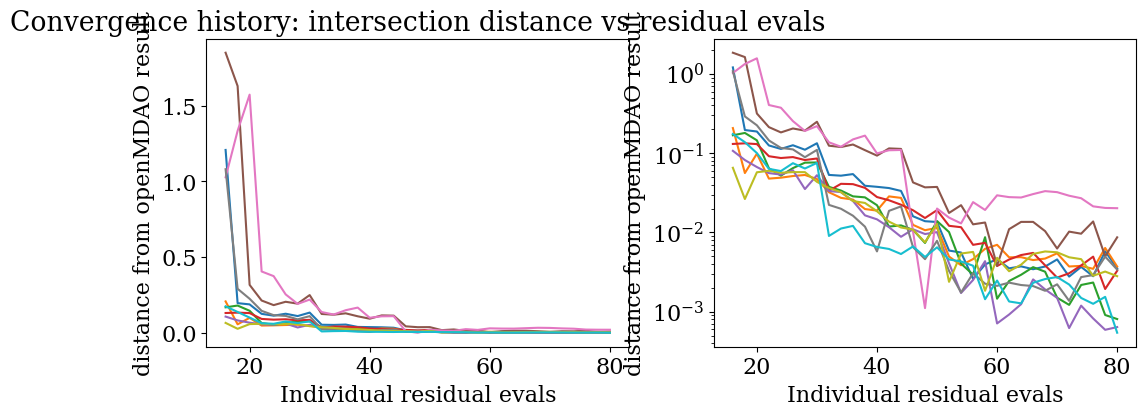

In [20]:
import torch
import matplotlib.pyplot as plt

history = torch.load("hist_rep_5.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

Text(0, 0.5, 'distance from openMDAO result')

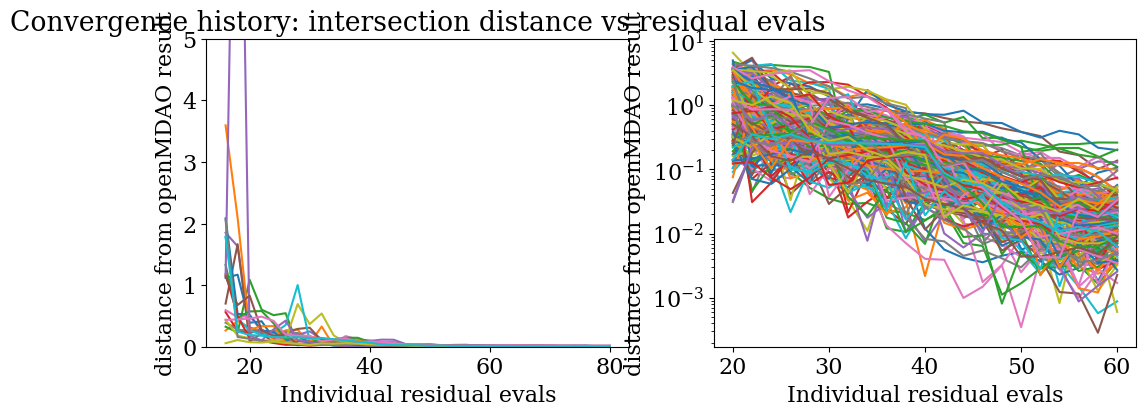

In [21]:
import torch
import matplotlib.pyplot as plt

# history = torch.load("hist_1.pt")
# num_evals = history["num_evals"]
# dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
for i in range(0,20):
    history = torch.load("hist_rep_" + str(i+1) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    plt.plot(num_evals, dist_history[:,5])
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')
host.set_ylim((0,5))

host = fig.add_subplot(122)
for i in range(0,20):
    history = torch.load("hist_" + str(i+1) + ".pt")
    num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

torch.Size([33, 10, 20])


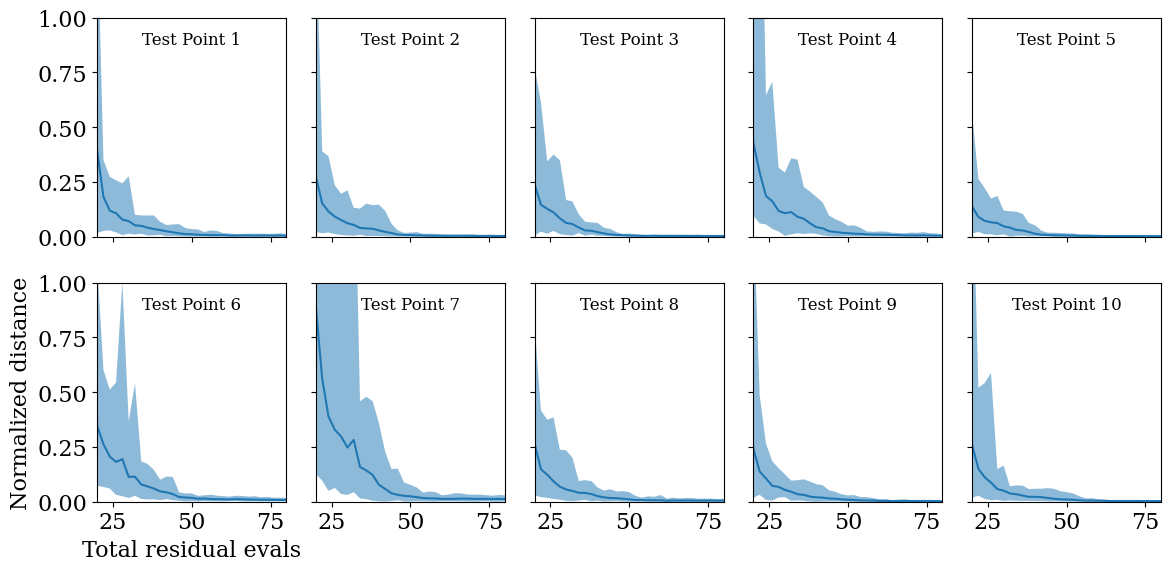

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

num_points = 10
num_runs = 20

# Collate results for all points.
for i in range(0,num_runs):
    filename = "hist_rep_" + str(i+1) + ".pt"
    history = torch.load(filename)
    # num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    if i==0:
        # Initialize history
        # Assume number of evals is the same for all
        num_evals = history["num_evals"]
        dist_history_all = dist_history
    else:
        # Stack all runs into one 3D tensor.
        # Row = iteration count
        # Column = test point index
        # Depth = training run index
        dist_history_all = torch.dstack((dist_history_all,
                                         dist_history))

print(dist_history_all.shape)

# Plot for each point.
fig = plt.figure(figsize=(12,6))

for i in range(0,num_points):
    ax = fig.add_subplot(2,5,i+1)
    dist_history = dist_history_all[:,i,:] # Get slice corresponding to point
    
    # fig = plt.figure(figsize=(12,4))
    ax.plot(num_evals, dist_history.mean(1))
    ax.fill_between(num_evals, dist_history.max(1).values, dist_history.min(1).values, 
                     alpha=0.5)
    ax.set_xlim((20,80))
    ax.set_ylim((0,1))
    ax.text(0.5, 0.88,
            'Test Point ' + str(i+1),
            horizontalalignment='center',
            transform=ax.transAxes,
            fontsize=12)

    # Remove y axis labels for all except first column
    if i % 5 != 0:
        ax.set_yticklabels([])

    # Remove x axis labels for top row
    if i < 5:
        ax.set_xticklabels([])
    
    if i == 5:
        ax.set_xlabel("Total residual evals")
        ax.set_ylabel("Normalized distance")

plt.tight_layout()
# plt.show();
plt.savefig("satellite_convergence_mean.svg");

C:\Users\kaily\AppData\Local\Temp\ipykernel_17536\130620744.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_vec = torch.tensor(x_input[5,...]) # use input from above


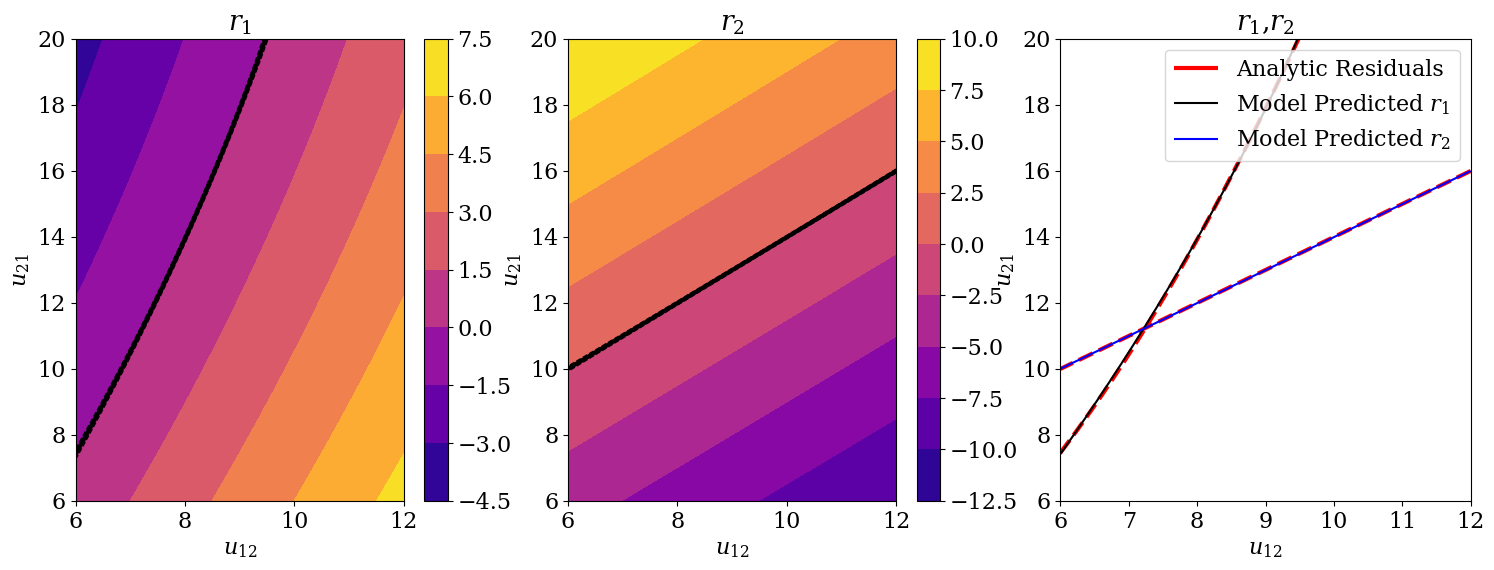

In [55]:
## Review comment
# Please avoid hardcoding!


import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = sat_prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor(x_input[5,...]) # use input from above
# input_vec = torch.rand(5)*2 # random input
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
sat_prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = sat_prob.res[:,0]
r2vec = sat_prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,0])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,1])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$u_{12}$')
ax1.set_ylabel(r'$u_{21}$')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$u_{12}$')
ax2.set_ylabel(r'$u_{21}$')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$u_{12}$')
ax3.set_ylabel(r'$u_{21}$')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

#### Show Incremental Result

In [62]:
import numpy as np
import torch
from test_functions import Satellite
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

num_train = 5
maxiters = 5

# Initial training
sat_prob = Satellite()
gpmodel = train_multitask_gp(sat_prob, num_train=num_train, seed=1111+i) 
gpmodel.save('satellite_gp_increment_0.pt')

# Save model every 5 iterations
for i in range(0,7):
    print('Increment',i+1,"\r")
    active_learning_loop(gpmodel,acq_method = 'entropy', maxiters = maxiters, 
                         disp = True, log_hyperparams = False)
    # Save result
    gpmodel.save('satellite_gp_increment_' + str(i+1) + '.pt')


Increment 1 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done
Increment 2 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done
Increment 3 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done
Increment 4 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done
Increment 5 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done
Increment 6 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done
Increment 7 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
done


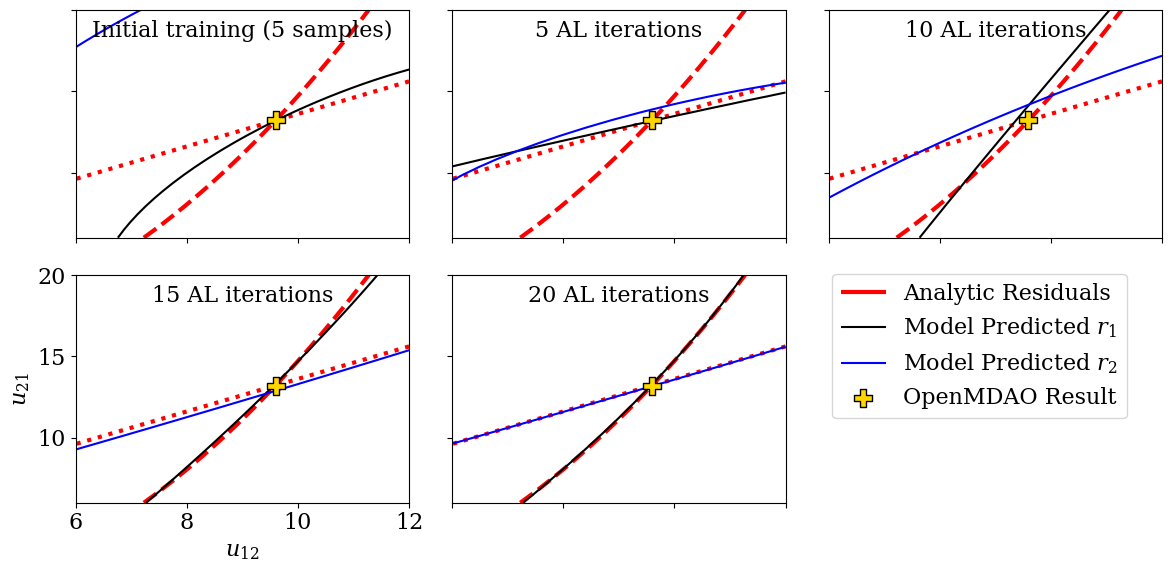

In [71]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
from scipy.stats import qmc

tasks = [0,1]

# Load model
gpmodel = TrainedGP()
gpmodel.load("satellite_gp_increment_0.pt")
prob = gpmodel.problem
bounds = prob.bounds
in_dim = prob.input_dim

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
sampler = qmc.LatinHypercube(d=5,seed=1234)
input_vec = torch.tensor(qmc.scale(sampler.random(n=1), bounds[0,:in_dim], bounds[1,:in_dim]))
truth = prob.from_OpenMDAO(input_vec)

npts = 30
test_points, xvec, yvec = assemble_test_points(prob, tasks, input_vec, npts=npts)

# Plot
fig = plt.figure(figsize=(12,6))

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))

for i in range(0,5):
    # Load model
    gpmodel = TrainedGP()
    gpmodel.load("satellite_gp_increment_" + str(i) + ".pt")
    
    # Unpack result
    problem = gpmodel.problem
    mt_model = gpmodel.model
    y = gpmodel.train_y
    
    # Analytic
    problem.set_vars(test_points)
    res = problem.res

    r1vec = res[:,tasks[0]]
    r2vec = res[:,tasks[1]]
    
    # Predictions
    test_x = normalize(test_points,problem.bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
    test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
    # test_x1.requires_grad = True
    
    prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
    prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

    # Plot
    ax = fig.add_subplot(2,3,i+1)

    # Contours
    s1 = ax.contour(xvec,yvec,r1vec.reshape(npts,npts),
                     levels=[0.],
                     linestyles='--', linewidths=3, colors='r')
    s1_artist,_ = s1.legend_elements()
    
    ax.contour(xvec,yvec,r2vec.reshape(npts,npts),
                levels=[0.],
                linestyles=':', linewidths=3, colors='r')
    
    s2 = ax.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='k')
    s2_artist,_ = s2.legend_elements()
    
    s3 = ax.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='blue')
    s3_artist,_ = s3.legend_elements()
    
    s4 = ax.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)

    if i != 0:
        ax.text(0.5, 0.88,
                str(i*5) + ' AL iterations',
                horizontalalignment='center',
                transform=ax.transAxes,
                fontsize=16)
    else:
        ax.text(0.5, 0.88, 
                'Initial training (5 samples)',
                horizontalalignment='center',
                transform=ax.transAxes,
                fontsize=16
               )

    # Remove y axis labels for all except first column
    if i != 3:
        ax.set_yticklabels([])
        ax.set_xticklabels([])
    
    if i == 3:
        ax.set_xlabel(r'$u_{12}$')
        ax.set_ylabel(r'$u_{21}$')

        # print('elapsed:', time.time()-t)

fig.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],
           ['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'],
           loc="center right",
           bbox_to_anchor=(0.96,0.4)
          )
plt.tight_layout()
plt.savefig("satellite_incremental_training.svg")
plt.show()

#### Show entropy progression

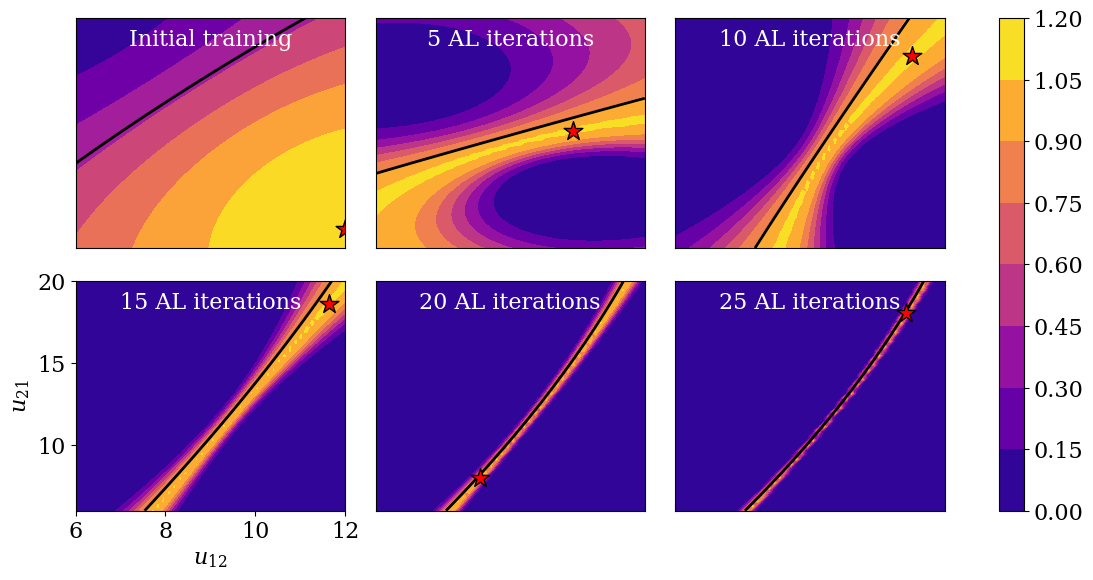

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
from scipy.stats import qmc
from acquisition import entropy

tasks = [0,1]

# Load model
gpmodel = TrainedGP()
gpmodel.load("satellite_gp_increment_0.pt")
prob = gpmodel.problem
bounds = prob.bounds
in_dim = prob.input_dim

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
sampler = qmc.LatinHypercube(d=5,seed=1234)
input_vec = torch.tensor(qmc.scale(sampler.random(n=1), bounds[0,:in_dim], bounds[1,:in_dim]))
# truth = prob.from_OpenMDAO(input_vec)

npts = 50
test_points, xvec, yvec = assemble_test_points(prob, tasks, input_vec, npts=npts)

# Plot
fig = plt.figure(figsize=(12,6))

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))

for i in range(0,6):
    # Load model
    gpmodel = TrainedGP()
    gpmodel.load("satellite_gp_increment_" + str(i) + ".pt")
    
    # Unpack result
    problem = gpmodel.problem
    mt_model = gpmodel.model
    y = gpmodel.train_y
    
    # Analytic
    problem.set_vars(test_points)
    res = problem.res

    r1vec = res[:,tasks[0]]
    # r2vec = res[:,tasks[1]]
    
    # Predictions
    test_x = normalize(test_points,problem.bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
    # test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
    
    # prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
    prediction1 = mt_model.likelihood(mt_model(test_x1))
    # prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

    # Plot
    ax = fig.add_subplot(2,3,i+1)

    # Contours
    # Entropy
    ent1 = entropy(test_x1,mt_model).detach().numpy().reshape(npts,npts)
    ent1 = np.maximum(ent1,0)
    cf = ax.contourf(xvec,yvec,ent1,
                    cmap='plasma')
    # s0_artist,_ = s0.legend_elements()
    
    
    # Analytic
    # s1 = ax.contour(xvec,yvec,r1vec.reshape(npts,npts),
    #                  levels=[0.],
    #                  linestyles='--', linewidths=3, colors='r')
    # s1_artist,_ = s1.legend_elements()

    # ax.contour(xvec,yvec,r2vec.reshape(npts,npts),
    #             levels=[0.],
    #             linestyles=':', linewidths=3, colors='r')
    
    # Model prediction   
    s2 = ax.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=2, colors='k')
    s2_artist,_ = s2.legend_elements()
    
    # s3 = ax.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
    #             levels=[0.],
    #             linestyles='-', linewidths=1.5, colors='blue')
    # s3_artist,_ = s3.legend_elements()
    
    s4 = ax.scatter(xvec.ravel()[np.argmax(ent1)], 
                    yvec.ravel()[np.argmax(ent1)], 
                    marker='*',c='r',s=200, edgecolor='k', zorder=2.5)

    if i != 0:
        ax.text(0.5, 0.88,
                str(i*5) + ' AL iterations',
                horizontalalignment='center',
                transform=ax.transAxes,
                fontsize=16,
                color='w'
               )
    else:
        ax.text(0.5, 0.88, 
                'Initial training',
                horizontalalignment='center',
                transform=ax.transAxes,
                fontsize=16,
                color='w'
               )

    # Remove y axis labels for all except first column
    if i != 3:
        ax.set_yticklabels([])
        ax.set_xticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
    
    if i == 3:
        ax.set_xlabel(r'$u_{12}$')
        ax.set_ylabel(r'$u_{21}$')

        # print('elapsed:', time.time()-t)

# fig.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],
#            ['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'],
#            loc="center right",
#            bbox_to_anchor=(0.96,0.4)
#           )
plt.tight_layout()
fig.colorbar(cf, ax=fig.axes)
plt.savefig("satellite_incremental_entropy.svg")
plt.show()

#### Show different sample points

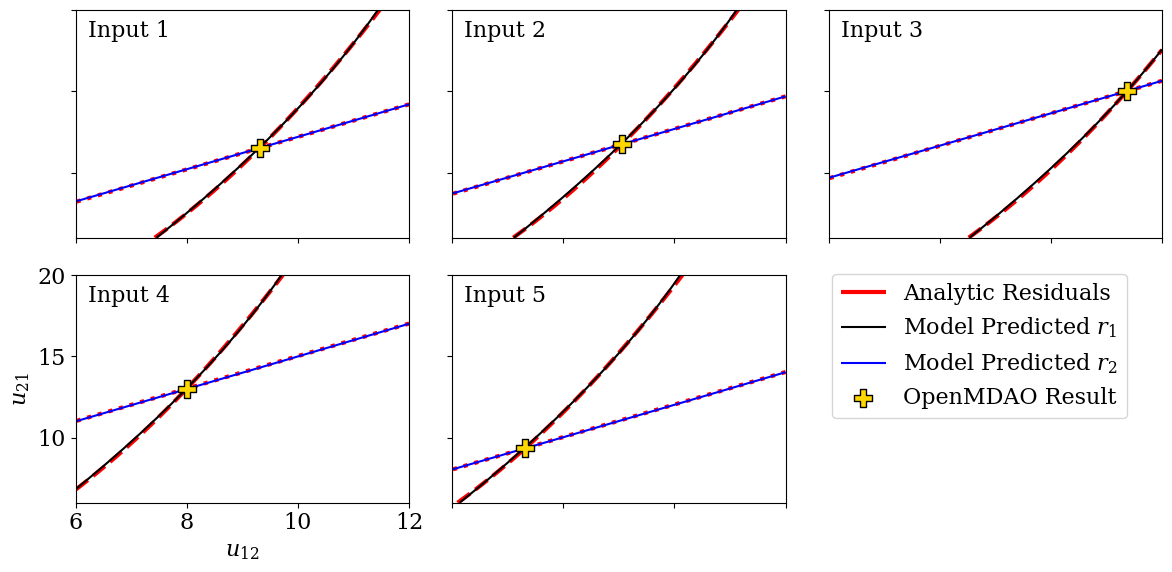

In [90]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
from scipy.stats import qmc

tasks = [0,1]

# Load model
gpmodel = TrainedGP()
gpmodel.load("satellite_gp_increment_6.pt")

# Unpack result
problem = gpmodel.problem
bounds = problem.bounds
in_dim = problem.input_dim
out_dim = problem.coupling_dim
mt_model = gpmodel.model
y = gpmodel.train_y

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
sampler = qmc.LatinHypercube(d=5,seed=1234)
num_samples = 6
input_list = torch.tensor(qmc.scale(sampler.random(n=num_samples), bounds[0,:in_dim], bounds[1,:in_dim]))

# truth = torch.empty(0,out_dim)
# for vec in input_vec:
#     truth = torch.vstack((truth,problem.from_OpenMDAO(vec)))

# Plot
fig = plt.figure(figsize=(12,6))

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))

for i in range(0,5):
    input_vec = input_list[i]
    truth = problem.from_OpenMDAO(input_vec)
    
    npts = 30
    test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)
    # Analytic
    problem.set_vars(test_points)
    res = problem.res

    r1vec = res[:,tasks[0]]
    r2vec = res[:,tasks[1]]
    
    # Predictions
    test_x = normalize(test_points,problem.bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
    test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
    # test_x1.requires_grad = True
    
    prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
    prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

    # Plot
    ax = fig.add_subplot(2,3,i+1)

    # Contours
    s1 = ax.contour(xvec,yvec,r1vec.reshape(npts,npts),
                     levels=[0.],
                     linestyles='--', linewidths=3, colors='r')
    s1_artist,_ = s1.legend_elements()
    
    ax.contour(xvec,yvec,r2vec.reshape(npts,npts),
                levels=[0.],
                linestyles=':', linewidths=3, colors='r')
    
    s2 = ax.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='k')
    s2_artist,_ = s2.legend_elements()
    
    s3 = ax.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='blue')
    s3_artist,_ = s3.legend_elements()
    
    s4 = ax.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)

    ax.text(0.16, 0.88,
            'Input ' + str(i+1),
            horizontalalignment='center',
            transform=ax.transAxes,
            fontsize=16)

    # Remove y axis labels for all except first column
    if i != 3:
        ax.set_yticklabels([])
        ax.set_xticklabels([])
    
    if i == 3:
        ax.set_xlabel(r'$u_{12}$')
        ax.set_ylabel(r'$u_{21}$')

        # print('elapsed:', time.time()-t)

fig.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],
           ['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'],
           loc="center right",
           bbox_to_anchor=(0.96,0.4)
          )
plt.tight_layout()
plt.savefig("satellite_input_sweep.svg")
plt.show()

## Aerostructural Example

In [25]:
import numpy as np
import torch

In [26]:
from test_functions import Aerostructures
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

dtype = torch.float64
device= "cpu"
bounds  = torch.tensor([[0.  ],
                        [300.]], dtype=dtype, device=device) # always a 2 x d tensor
# x_input = unnormalize(torch.rand(10,1), bounds=bounds)
x_input = unnormalize(torch.linspace(1e-4,1,10).reshape(-1,1), bounds=bounds)

for i in range(0,20):
    print('Run',i+1,"\r")
    filename = "aero_hist_rep_" + str(i+1) + ".pt"

    prob = Aerostructures()
    gpmodel = train_multitask_gp(prob, num_train=10, seed=1111+i) 
    active_learning_loop(gpmodel, acq_method = 'entropy', maxiters = 80, 
                         disp = True, save_hist = (x_input, filename, 'openmdao'), 
                         log_hyperparams = True, rep_count=i)


Run 1 
Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

num_points = 10
num_runs = 20

# Collate results for all points.
for i in range(0,20):
    filename = "aero_hist_rep_" + str(i+1) + ".pt"
    history = torch.load(filename)
    # num_evals = history["num_evals"]
    dist_history = history["dist_history"] 
    # dist_history = np.minimum.accumulate(dist_history)
    # print(dist_history[:,9])
    if i==0:
        # Initialize history
        # Assume number of evals is the same for all
        num_evals = history["num_evals"]
        dist_history_all = dist_history
    else:
        # Stack all runs into one 3D tensor.
        # Row = iteration count
        # Column = test point index
        # Depth = training run index
        dist_history_all = torch.dstack((dist_history_all,
                                         dist_history))

# print(dist_history_all.shape)

# Plot for each point.
fig = plt.figure(figsize=(12,6))

for i in range(0,num_points):
    ax = fig.add_subplot(2,5,i+1)
    dist_history = dist_history_all[:,i,:] # Get slice corresponding to point
    
    # fig = plt.figure(figsize=(12,4))
    ax.plot(num_evals, dist_history.mean(1))
    # print(dist_history.max(1).values)
    # ax.plot(num_evals, dist_history.max(1).values)
    ax.fill_between(num_evals, dist_history.max(1).values, dist_history.min(1).values, 
                     alpha=0.5)
    ax.set_xlim((20,max(num_evals)))
    ax.set_ylim((0,10))
    ax.text(0.5, 0.88,
            'Test Point ' + str(i+1),
            horizontalalignment='center',
            transform=ax.transAxes,
            fontsize=12)

    if i == 5:
        ax.set_xlabel("# function evals", fontsize=12)
        ax.set_ylabel("Distance from OpenMDAO", fontsize=12)

# plt.tight_layout()
    
# plt.show();
plt.savefig("aerostrux_convergence_mean.png");



#### Show different sample points

In [28]:
from test_functions import Aerostructures
from gp import train_multitask_gp
from acquisition import multitask_acquisition, optimize_acquisition
from active_learning import active_learning_loop
from botorch.utils.transforms import normalize, unnormalize, standardize 

dtype = torch.float64
device= "cpu"
bounds  = torch.tensor([[0.  ],
                        [300.]], dtype=dtype, device=device) # always a 2 x d tensor
# x_input = unnormalize(torch.rand(10,1), bounds=bounds)
input_list = unnormalize(torch.linspace(1e-4,1,10).reshape(-1,1), bounds=bounds)

filename = "aero_hist.pt"

prob = Aerostructures()
gpmodel = train_multitask_gp(prob, num_train=10, seed=1111) 
active_learning_loop(gpmodel, acq_method = 'entropy', maxiters = 80, 
                     disp = True, save_hist = (input_list, filename, 'openmdao'), 
                     log_hyperparams = False)

gpmodel.save("aerostrux_gp_trained.pt")

Iter 1
Iter 2
Iter 3
Iter 4
Iter 5
Iter 6
Iter 7
Iter 8
Iter 9
Iter 10
Iter 11
Iter 12
Iter 13
Iter 14
Iter 15
Iter 16
Iter 17
Iter 18
Iter 19
Iter 20
Iter 21
Iter 22
Iter 23
Iter 24
Iter 25
Iter 26
Iter 27
Iter 28
Iter 29
Iter 30
Iter 31
Iter 32
Iter 33
Iter 34
Iter 35
Iter 36
Iter 37
Iter 38
Iter 39
Iter 40
Iter 41
Iter 42
Iter 43
Iter 44
Iter 45
Iter 46
Iter 47
Iter 48
Iter 49
Iter 50
Iter 51
Iter 52
Iter 53
Iter 54
Iter 55
Iter 56
Iter 57
Iter 58
Iter 59
Iter 60
Iter 61
Iter 62
Iter 63
Iter 64
Iter 65
Iter 66
Iter 67
Iter 68
Iter 69
Iter 70
Iter 71
Iter 72
Iter 73
Iter 74
Iter 75
Iter 76
Iter 77
Iter 78
Iter 79
Iter 80
done


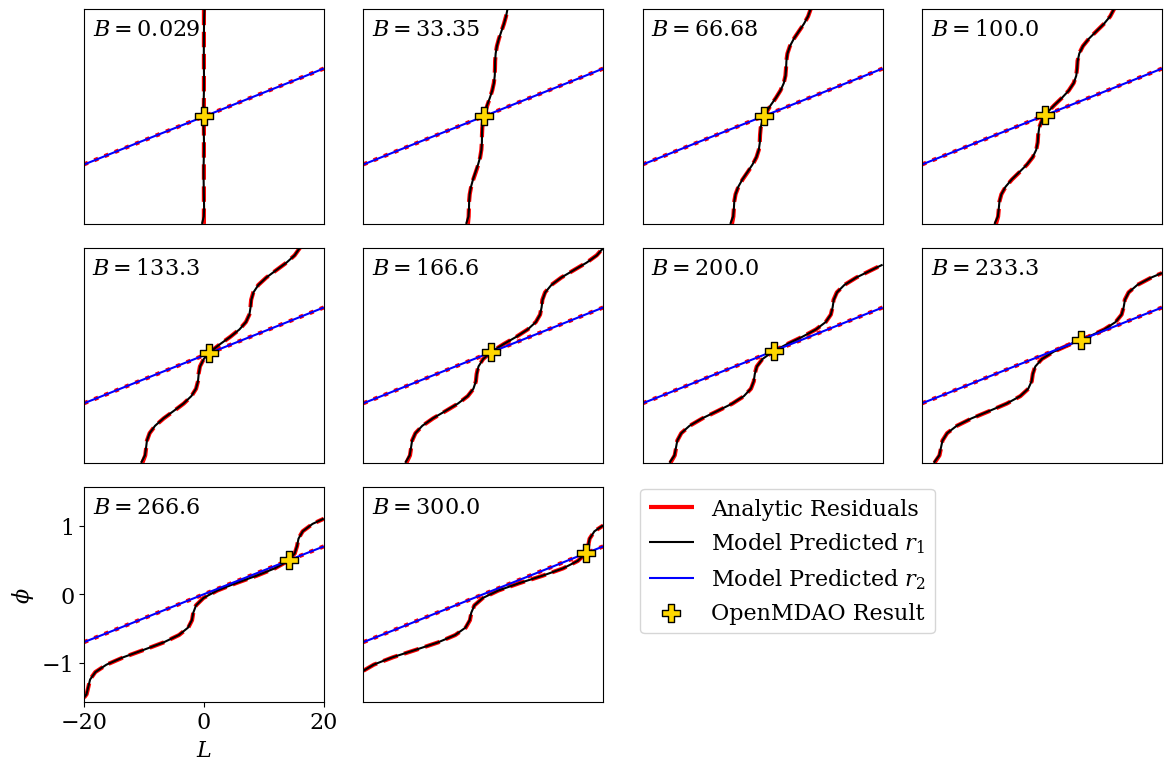

In [92]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize, assemble_test_points
from gp import TrainedGP
tasks = [0,1]

# Load model
gpmodel = TrainedGP()
gpmodel.load("aerostrux_gp_trained.pt")

# Unpack result
problem = gpmodel.problem
bounds = problem.bounds
in_dim = problem.input_dim
out_dim = problem.coupling_dim
mt_model = gpmodel.model
y = gpmodel.train_y

bounds  = torch.tensor([[0.  ],
                        [300.]], dtype=dtype, device=device) # always a 2 x d tensor
# x_input = unnormalize(torch.rand(10,1), bounds=bounds)
input_list = unnormalize(torch.linspace(1e-4,1,10).reshape(-1,1), bounds=bounds)

# Plot
fig = plt.figure(figsize=(12,8))

plt.rcParams['font.size'] = 16
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

cbformat = ticker.ScalarFormatter()
cbformat.set_scientific('%.2e')
cbformat.set_powerlimits((-3,3))

for i in range(0,10):
    input_vec = input_list[i]
    truth = problem.from_OpenMDAO(input_vec)
    
    npts = 30
    test_points, xvec, yvec = assemble_test_points(problem, tasks, input_vec, npts=npts)
    # Analytic
    problem.set_vars(test_points)
    res = problem.res

    r1vec = res[:,tasks[0]]
    r2vec = res[:,tasks[1]]
    
    # Predictions
    test_x = normalize(test_points,problem.bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[0]]) # task id1
    test_x2 = torch.column_stack([test_x, torch.ones(npts**2)*tasks[1]]) # task id2
    # test_x1.requires_grad = True
    
    prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,tasks[0]])
    prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,tasks[1]])

    # Plot
    ax = fig.add_subplot(3,4,i+1)

    # Contours
    s1 = ax.contour(xvec,yvec,r1vec.reshape(npts,npts),
                     levels=[0.],
                     linestyles='--', linewidths=3, colors='r')
    s1_artist,_ = s1.legend_elements()
    
    ax.contour(xvec,yvec,r2vec.reshape(npts,npts),
                levels=[0.],
                linestyles=':', linewidths=3, colors='r')
    
    s2 = ax.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='k')
    s2_artist,_ = s2.legend_elements()
    
    s3 = ax.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='blue')
    s3_artist,_ = s3.legend_elements()
    
    s4 = ax.scatter(truth[tasks[0]], truth[tasks[1]], marker='P',c='gold',s=150, edgecolor='k', zorder=2.5)

    ax.text(0.26, 0.88,
        (r'$B={%.5s}$' %(str(input_vec.item()))),
        horizontalalignment='center',
        transform=ax.transAxes,
        fontsize=16)

    # Remove y axis labels for all except first column
    if i != 8:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
    
    if i == 8:
        ax.set_xlabel(r'$L$')
        ax.set_ylabel(r'$\phi$')

        # print('elapsed:', time.time()-t)

fig.legend([s1_artist[0], s2_artist[0], s3_artist[0], s4],
           ['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$','OpenMDAO Result'],
           loc="center right",
           bbox_to_anchor=(0.8,0.28)
          )
plt.tight_layout()
plt.savefig("aerostrux_input_sweep.svg")
plt.show()

Text(0, 0.5, 'distance from openMDAO result')

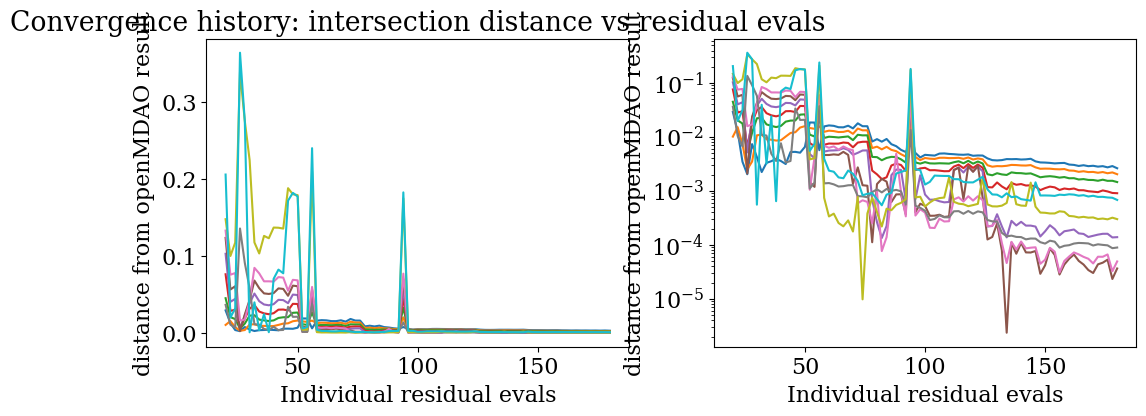

In [30]:
import torch
import matplotlib.pyplot as plt

history = torch.load("aero_hist.pt")
num_evals = history["num_evals"]
dist_history = history["dist_history"] 

fig = plt.figure(figsize=(12,4))

host = fig.add_subplot(121)
plt.plot(num_evals, dist_history)
host.set_title('Convergence history: intersection distance vs residual evals')
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

host = fig.add_subplot(122)
plt.semilogy(num_evals, dist_history)
host.set_xlabel('Individual residual evals')
host.set_ylabel('distance from openMDAO result')

In [ ]:
import torch
from utils import unstandardize

input_vec = x_input[8]
trial = 5

# Unpack result
mt_model = gpmodel.model
# y = gpmodel.train_y
bounds = prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = prob.res[:,0]
r2vec = prob.res[:,1]



for it in range(70,80):
    # print('iter ' + str(20+2*it))
    print('iter ' + str(it+1))
    
    # load model
    dir_name = 'log'
    snapshot = torch.load(dir_name + '/' + 'model_run_' + str(trial) + '_iter_' + str(it+1) + '.pt', weights_only = False)
    model_snapshot = snapshot["model"]
    y = snapshot["train_y"]
    
    # make predictions
    # npts = 40
    
    # Predictions
    test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                                 xvec.reshape(-1,1),
                                 yvec.reshape(-1,1)])
    test_x = normalize(test_x,bounds)
    test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
    test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
    
    prediction1 = unstandardize(model_snapshot.likelihood(model_snapshot(test_x1)), y[:,0])
    prediction2 = unstandardize(model_snapshot.likelihood(model_snapshot(test_x2)), y[:,1])

    fig = plt.figure(figsize=(18,6))

    # plot
    # r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax1 = fig.add_subplot(131)
    cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                      cmap = 'plasma')
    ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
                levels=[0.], 
                linestyles='-', linewidths=3, colors='k')
    ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    # ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
    fig.colorbar(cf1)
    ax1.set_title(r'$r_1$')
    ax1.set_xlabel(r'$L$ [kN]')
    ax1.set_ylabel(r'$\phi$ [rad]')
    
    
    
    # r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax2 = fig.add_subplot(132)
    cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                      cmap = 'plasma')
    ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
                levels=[0.], 
                linestyles='-', linewidths=3, colors='k')
    ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
                levels=[0.], linestyles='--', linewidths=1, colors='k')
    # ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
    fig.colorbar(cf2)
    ax2.set_title(r'$r_2$')
    ax2.set_xlabel(r'$L$ [kN]')
    ax2.set_ylabel(r'$\phi$ [rad]')
    
    
    
    # both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    ax3 = fig.add_subplot(133)
    # cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
    #              cmap = 'plasma')
    # fig.colorbar(cf3)
    s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
                levels=[0.],
                linestyles='--', linewidths=3, colors='r')
    s1_artist,_ = s1.legend_elements()
    ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
                levels=[0.],
                linestyles='--', linewidths=3, colors='r')
    s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='k')
    s2_artist,_ = s2.legend_elements()
    s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
                levels=[0.],
                linestyles='-', linewidths=1.5, colors='b')
    s3_artist,_ = s3.legend_elements()
    ax3.set_title(r'$r_1$,$r_2$')
    ax3.set_xlabel(r'$L$ [kN]')
    ax3.set_ylabel(r'$\phi$ [rad]')
    #ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
    ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import torch
from botorch.utils.transforms import normalize
from utils import unstandardize

# This assumes that there are two coupling variables that we care about.

# Unpack result
mt_model = gpmodel.model
y = gpmodel.train_y
bounds = prob.bounds
coupling_bounds = torch.transpose(bounds[:,-2:],0,1)

# Select inputs at which to make prediction ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_vec = torch.tensor([233])
# input_vec = torch.rand(5)*2
npts = 40

# Generate test points 
xvec, yvec = torch.meshgrid(torch.linspace(*coupling_bounds[0,:],npts), # first coupling variable
                            torch.linspace(*coupling_bounds[1,:],npts), # second coupling variable
                            indexing='ij')

# Analytic
prob.set_vars(torch.column_stack([input_vec.repeat(npts**2,1),xvec.reshape(-1,1),yvec.reshape(-1,1)]))

r1vec = prob.res[:,0]
r2vec = prob.res[:,1]

# Predictions
test_x = torch.column_stack([input_vec.repeat(npts**2,1),
                             xvec.reshape(-1,1),
                             yvec.reshape(-1,1)])
test_x = normalize(test_x,bounds)
test_x1 = torch.column_stack([test_x, torch.ones(npts**2,1)*0]) # task id1
test_x2 = torch.column_stack([test_x, torch.ones(npts**2,1)*1]) # task id2
# test_x1.requires_grad = True

# Write a function unstandardize() to do this.
# prediction1 = y.mean().item()+(mt_model.likelihood(mt_model(test_x1)))*y.std().item()
# prediction2 = y.mean().item()+(mt_model.likelihood(mt_model(test_x2)))*y.std().item()
prediction1 = unstandardize(mt_model.likelihood(mt_model(test_x1)), y[:,0])
prediction2 = unstandardize(mt_model.likelihood(mt_model(test_x2)), y[:,1])

fig = plt.figure(figsize=(18,6))

# r1 +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax1 = fig.add_subplot(131)
cf1 = ax1.contourf(xvec, yvec, prediction1.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax1.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) + 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax1.contour(xvec, yvec, prediction1.mean.detach().reshape(npts, npts) - 2.* prediction1.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax1.scatter(train_x1[...,-2],train_x1[...,-1],c='w',s=15)
fig.colorbar(cf1)
ax1.set_title(r'$r_1$')
ax1.set_xlabel(r'$L$ [kN]')
ax1.set_ylabel(r'$\phi$ [rad]')



# r2 residual +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax2 = fig.add_subplot(132)
cf2 = ax2.contourf(xvec, yvec, prediction2.mean.detach().numpy().reshape(npts,npts),
                  cmap = 'plasma')
ax2.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts), 
            levels=[0.], 
            linestyles='-', linewidths=3, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) + 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
ax2.contour(xvec, yvec, prediction2.mean.detach().reshape(npts, npts) - 2.* prediction2.stddev.detach().reshape(npts, npts), 
            levels=[0.], linestyles='--', linewidths=1, colors='k')
# ax2.scatter(train_x2[...,-2],train_x2[...,-1],c='w',s=15)
fig.colorbar(cf2)
ax2.set_title(r'$r_2$')
ax2.set_xlabel(r'$L$ [kN]')
ax2.set_ylabel(r'$\phi$ [rad]')



# both ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
ax3 = fig.add_subplot(133)
# cf3 = ax3.contourf(xvec,yvec,prediction3.mean.detach().numpy().reshape(40,40),
#              cmap = 'plasma')
# fig.colorbar(cf3)
s1 = ax3.contour(xvec,yvec,r1vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s1_artist,_ = s1.legend_elements()
ax3.contour(xvec,yvec,r2vec.reshape(npts,npts),
            levels=[0.],
            linestyles='--', linewidths=3, colors='r')
s2 = ax3.contour(xvec,yvec,prediction1.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='k')
s2_artist,_ = s2.legend_elements()
s3 = ax3.contour(xvec,yvec,prediction2.mean.detach().numpy().reshape(npts,npts),
            levels=[0.],
            linestyles='-', linewidths=1.5, colors='b')
s3_artist,_ = s3.legend_elements()
ax3.set_title(r'$r_1$,$r_2$')
ax3.set_xlabel(r'$L$ [kN]')
ax3.set_ylabel(r'$\phi$ [rad]')
#ax3.legend([s1_artist, s3_artist], ['Analytic Residuals','Model Residuals'])
ax3.legend([s1_artist[0], s2_artist[0], s3_artist[0]],['Analytic Residuals','Model Predicted $r_1$','Model Predicted $r_2$'])

In [ ]:
# from botorch.utils.transforms import standardize
# from utils import unstandardize

# test = torch.tensor([[-0.4777, -0.2158],
#         [ 0.0608,  0.9787],
#         [ 0.2262, -0.0768],
#         [ 0.5601, -0.9951],
#         [ 0.5964,  0.6110]])
# print(test)
# test = test + torch.tensor([0,10000]).repeat(5,1)
# print(test)
# print(test.mean(0))
# print(standardize(test))
# print(standardize(test).mean(0))